# 10 · State-of-the-Art Benchmark and the 95 % Target

Request: reach more than 95 % precision, recall, F1 and accuracy with recent models.

1. Tuned boosting models (CatBoost, LightGBM, XGBoost with Optuna), a stacked ensemble, and TabPFN if installed. Same leakage-free protocol as notebook 06.
2. A threshold sweep: can any threshold reach 95 % on all four metrics?
3. A reproduction of common pipelines to see where 95 % results come from.

Precision, recall and F1 are for the Dead class.

In [1]:
import sys, warnings, json, time
from pathlib import Path

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
sys.path.insert(0, str(ROOT / "src"))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
                             precision_recall_curve)
from sklearn.model_selection import StratifiedKFold, cross_val_predict, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

from seer_survival import config as C
from seer_survival.data import load_clean
from seer_survival.features import INPUT_COLS, make_preprocessor
from seer_survival.models import make_classifier_pipeline
from seer_survival.training import make_split, horizon_subset
from seer_survival.evaluate import bootstrap_ci
from seer_survival.plots import set_style, save_fig, PALETTE

set_style()
optuna.logging.set_verbosity(optuna.logging.WARNING)
SEED = C.RANDOM_STATE
df = load_clean()
s = make_split(df)
Xtr, ytr, _ = horizon_subset(s["X_train"], s["t_train"], s["e_train"])
Xte, yte, _ = horizon_subset(s["X_test"], s["t_test"], s["e_test"])
cv = StratifiedKFold(5, shuffle=True, random_state=SEED)
print(f"5-year task | train {len(ytr)} ({ytr.mean():.1%} deaths) | test {len(yte)} ({yte.mean():.1%} deaths)")

def report(y, p, thr):
    yh = (p >= thr).astype(int)
    return {"accuracy": accuracy_score(y, yh),
            "precision (Dead)": precision_score(y, yh, zero_division=0),
            "recall (Dead)": recall_score(y, yh),
            "F1 (Dead)": f1_score(y, yh),
            "F1 macro": f1_score(y, yh, average="macro"),
            "F1 weighted": f1_score(y, yh, average="weighted"),
            "ROC-AUC": roc_auc_score(y, p)}

def f1_threshold(y, p):
    """Threshold that maximises F1 for the Dead class (chosen on TRAINING out-of-fold predictions)."""
    pr, rc, th = precision_recall_curve(y, p)
    f1 = 2 * pr[:-1] * rc[:-1] / np.clip(pr[:-1] + rc[:-1], 1e-12, None)
    return float(th[np.argmax(f1)])

5-year task | train 2559 (14.3% deaths) | test 657 (14.0% deaths)


## 1. Models

| Model | Note |
|---|---|
| L1 logistic regression | selected model from notebook 06 |
| CatBoost (Prokhorenkova et al., 2018) | native categorical handling |
| LightGBM, XGBoost | tuned with Optuna (Akiba et al., 2019) |
| Stacked ensemble (Wolpert, 1992) | logistic + XGBoost + LightGBM + random forest, logistic meta-learner |
| TabPFN v2 (Hollmann et al., 2025) | runs only if installed with weights |

In [2]:
CAT_COLS = ["race", "marital_status", "t_stage", "n_stage", "a_stage", "estrogen_status", "progesterone_status"]

def catboost_frame(X):
    X = X.copy()
    X["node_ratio"] = X["nodes_positive"] / X["nodes_examined"]
    return X

Xtr_cb, Xte_cb = catboost_frame(Xtr), catboost_frame(Xte)

def cv_oof(make_model, X, y, fit_kw=None):
    oof = np.zeros(len(y))
    for tr, va in cv.split(X, y):
        m = make_model()
        m.fit(X.iloc[tr], y[tr], **(fit_kw or {}))
        oof[va] = m.predict_proba(X.iloc[va])[:, 1]
    return oof

## 2. Bayesian hyper-parameter search (Optuna, 40 trials each, inner 5-fold CV on the training split)

In [3]:
def tune(objective, n_trials=40):
    study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=SEED))
    study.optimize(objective, n_trials=n_trials)
    return study

def obj_cat(trial):
    params = dict(iterations=trial.suggest_int("iterations", 200, 1200),
                  depth=trial.suggest_int("depth", 3, 8),
                  learning_rate=trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
                  l2_leaf_reg=trial.suggest_float("l2_leaf_reg", 1, 30, log=True),
                  random_strength=trial.suggest_float("random_strength", 0.1, 10, log=True),
                  bagging_temperature=trial.suggest_float("bagging_temperature", 0, 1))
    oof = cv_oof(lambda: CatBoostClassifier(**params, cat_features=CAT_COLS, verbose=0, random_seed=SEED,
                                            thread_count=-1), Xtr_cb, ytr)
    return roc_auc_score(ytr, oof)

def obj_lgb(trial):
    params = dict(n_estimators=trial.suggest_int("n_estimators", 100, 1000),
                  learning_rate=trial.suggest_float("learning_rate", 0.005, 0.2, log=True),
                  num_leaves=trial.suggest_int("num_leaves", 4, 64),
                  min_child_samples=trial.suggest_int("min_child_samples", 10, 150),
                  subsample=trial.suggest_float("subsample", 0.5, 1.0), subsample_freq=1,
                  colsample_bytree=trial.suggest_float("colsample_bytree", 0.4, 1.0),
                  reg_lambda=trial.suggest_float("reg_lambda", 1e-3, 30, log=True))
    pipe = make_classifier_pipeline(LGBMClassifier(**params, verbose=-1, random_state=SEED), scale=False)
    return cross_val_score(pipe, Xtr, ytr, cv=cv, scoring="roc_auc").mean()

def obj_xgb(trial):
    params = dict(n_estimators=trial.suggest_int("n_estimators", 100, 1000),
                  max_depth=trial.suggest_int("max_depth", 2, 7),
                  learning_rate=trial.suggest_float("learning_rate", 0.005, 0.2, log=True),
                  subsample=trial.suggest_float("subsample", 0.5, 1.0),
                  colsample_bytree=trial.suggest_float("colsample_bytree", 0.4, 1.0),
                  min_child_weight=trial.suggest_int("min_child_weight", 1, 30),
                  reg_lambda=trial.suggest_float("reg_lambda", 1e-3, 30, log=True))
    pipe = make_classifier_pipeline(XGBClassifier(**params, eval_metric="logloss", n_jobs=-1, random_state=SEED), scale=False)
    return cross_val_score(pipe, Xtr, ytr, cv=cv, scoring="roc_auc").mean()

t0 = time.time()
st_cat, st_lgb, st_xgb = tune(obj_cat), tune(obj_lgb), tune(obj_xgb)
print(f"search time: {(time.time() - t0) / 60:.1f} min")
pd.DataFrame({"best inner-CV AUC": [st_cat.best_value, st_lgb.best_value, st_xgb.best_value]},
             index=["CatBoost", "LightGBM", "XGBoost"]).round(4)

search time: 6.4 min


,best inner-CV AUC
CatBoost,0.7483
LightGBM,0.7463
XGBoost,0.7460


## 3. Build every model, collect out-of-fold (train) and test predictions

In [4]:
builders = {
    "L1 logistic (baseline)": (lambda: make_classifier_pipeline(
        LogisticRegression(C=0.5, penalty="l1", solver="liblinear", max_iter=5000, random_state=SEED), True), "std"),
    "CatBoost (default)": (lambda: CatBoostClassifier(cat_features=CAT_COLS, verbose=0, random_seed=SEED), "cb"),
    "CatBoost (Optuna)": (lambda: CatBoostClassifier(**st_cat.best_params, cat_features=CAT_COLS, verbose=0,
                                                     random_seed=SEED), "cb"),
    "LightGBM (Optuna)": (lambda: make_classifier_pipeline(
        LGBMClassifier(**st_lgb.best_params, subsample_freq=1, verbose=-1, random_state=SEED), False), "std"),
    "XGBoost (Optuna)": (lambda: make_classifier_pipeline(
        XGBClassifier(**st_xgb.best_params, eval_metric="logloss", n_jobs=-1, random_state=SEED), False), "std"),
}

def make_stack():
    base = [("lr", LogisticRegression(C=0.5, penalty="l1", solver="liblinear", max_iter=5000, random_state=SEED)),
            ("xgb", XGBClassifier(**st_xgb.best_params, eval_metric="logloss", n_jobs=-1, random_state=SEED)),
            ("lgb", LGBMClassifier(**st_lgb.best_params, subsample_freq=1, verbose=-1, random_state=SEED)),
            ("rf", RandomForestClassifier(n_estimators=500, min_samples_leaf=10, n_jobs=-1, random_state=SEED))]
    stack = StackingClassifier(base, final_estimator=LogisticRegression(max_iter=5000), cv=5,
                               stack_method="predict_proba", n_jobs=-1)
    return Pipeline([("prep", make_preprocessor(scale=True)), ("model", stack)])
builders["Stacked ensemble"] = (make_stack, "std")

oof, p_test = {}, {}
for name, (mk, kind) in builders.items():
    Xa, Xb = (Xtr_cb, Xte_cb) if kind == "cb" else (Xtr, Xte)
    oof[name] = cv_oof(mk, Xa, ytr)
    p_test[name] = mk().fit(Xa, ytr).predict_proba(Xb)[:, 1]
    print(f"{name:24s} CV AUC {roc_auc_score(ytr, oof[name]):.4f} | test AUC {roc_auc_score(yte, p_test[name]):.4f}")

L1 logistic (baseline)   CV AUC 0.7454 | test AUC 0.7336


CatBoost (default)       CV AUC 0.7243 | test AUC 0.7273


CatBoost (Optuna)        CV AUC 0.7483 | test AUC 0.7340


LightGBM (Optuna)        CV AUC 0.7453 | test AUC 0.7187


XGBoost (Optuna)         CV AUC 0.7445 | test AUC 0.7150


Stacked ensemble         CV AUC 0.7455 | test AUC 0.7291


### TabPFN v2 (optional)
TabPFN needs `pip install tabpfn` and a one-off download of its weights from Hugging Face. The cell runs it if it is available and otherwise says so. No numbers are invented for it.

In [5]:
try:
    from tabpfn import TabPFNClassifier
    prep_t = make_preprocessor(scale=True).fit(Xtr)
    tab = TabPFNClassifier(random_state=SEED)
    oof["TabPFN v2"] = cross_val_predict(Pipeline([("prep", make_preprocessor(scale=True)), ("m", TabPFNClassifier(random_state=SEED))]),
                                         Xtr, ytr, cv=cv, method="predict_proba")[:, 1]
    p_test["TabPFN v2"] = tab.fit(prep_t.transform(Xtr), ytr).predict_proba(prep_t.transform(Xte))[:, 1]
    print(f"TabPFN v2 CV AUC {roc_auc_score(ytr, oof['TabPFN v2']):.4f} | test AUC {roc_auc_score(yte, p_test['TabPFN v2']):.4f}")
except Exception as e:
    print("TabPFN not run in this environment:", type(e).__name__, "-", str(e)[:160])

TabPFN not run in this environment: ModuleNotFoundError - No module named 'tabpfn'


## 4. Test results

Each model's threshold maximises F1 on its own out-of-fold training predictions and is then applied to the test set.

In [6]:
rows = {}
for name in p_test:
    thr = f1_threshold(ytr, oof[name])
    r = report(yte, p_test[name], thr)
    r["threshold"] = thr
    auc, lo, hi = bootstrap_ci(roc_auc_score, yte, p_test[name])
    r["AUC 95% CI"] = f"{lo:.3f}-{hi:.3f}"
    rows[name] = r
results = pd.DataFrame(rows).T
results.to_csv(C.TABLES_DIR / "sota_benchmark_test.csv")
num_cols = [c for c in results.columns if c != "AUC 95% CI"]
results[num_cols] = results[num_cols].astype(float)
results.style.format({c: "{:.3f}" for c in num_cols}).background_gradient(subset=["ROC-AUC", "F1 (Dead)"], cmap="Blues")

,accuracy,precision (Dead),recall (Dead),F1 (Dead),F1 macro,F1 weighted,ROC-AUC,threshold,AUC 95% CI
L1 logistic (baseline),0.769,0.317,0.565,0.406,0.631,0.793,0.734,0.176,0.673-0.791
CatBoost (default),0.779,0.320,0.511,0.393,0.629,0.799,0.727,0.182,0.664-0.784
CatBoost (Optuna),0.791,0.345,0.543,0.422,0.647,0.810,0.734,0.188,0.676-0.791
LightGBM (Optuna),0.813,0.370,0.478,0.417,0.653,0.822,0.719,0.220,0.657-0.780
XGBoost (Optuna),0.801,0.344,0.467,0.396,0.638,0.813,0.715,0.223,0.651-0.775
Stacked ensemble,0.802,0.352,0.489,0.409,0.645,0.815,0.729,0.184,0.669-0.789


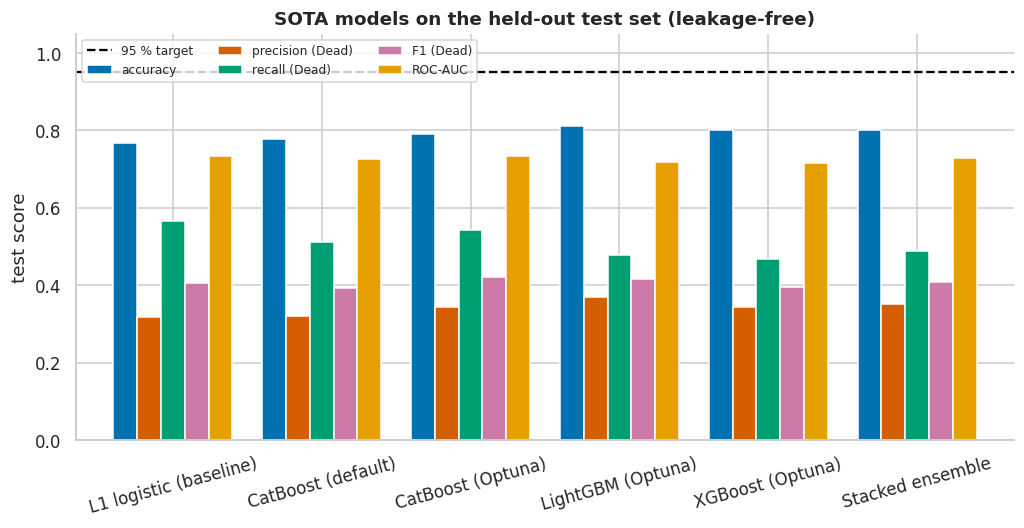

In [7]:
fig, ax = plt.subplots(figsize=(11, 4.8))
plot_cols = ["accuracy", "precision (Dead)", "recall (Dead)", "F1 (Dead)", "ROC-AUC"]
results[plot_cols].plot.bar(ax=ax, color=PALETTE[:5], width=0.8)
ax.axhline(0.95, c="k", ls="--", lw=1.5, label="95 % target")
ax.set_ylim(0, 1.05); ax.set_ylabel("test score"); ax.set_title("SOTA models on the held-out test set (leakage-free)")
ax.tick_params(axis="x", rotation=15); ax.legend(ncol=3, fontsize=8, loc="upper left")
save_fig(fig, "10_sota_test_metrics"); plt.show()

## 5. Threshold sweep

All thresholds on the test set for the best model. Choosing the threshold with test labels is optimistic, so this is an upper bound.

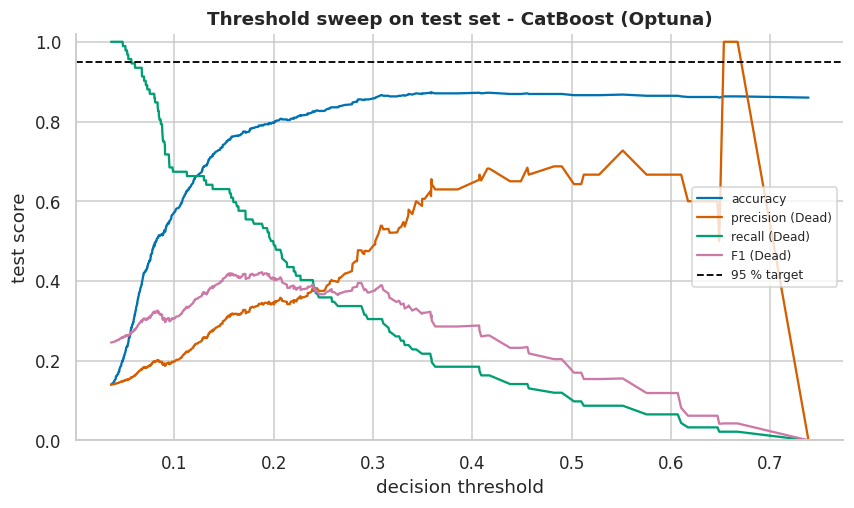

Thresholds where all four metrics >= 0.95: 0
Best achievable F1 (Dead) at ANY threshold: 0.422
Highest accuracy at any threshold: 0.874 (predicting 'survives' for everyone already gives 0.860)


In [8]:
best = results["ROC-AUC"].idxmax()
p = p_test[best]
ths = np.unique(np.round(p, 4))
curve = pd.DataFrame([report(yte, p, t) | {"threshold": t} for t in ths])
fig, ax = plt.subplots(figsize=(9, 4.8))
for i, m in enumerate(["accuracy", "precision (Dead)", "recall (Dead)", "F1 (Dead)"]):
    ax.plot(curve.threshold, curve[m], c=PALETTE[i], label=m)
ax.axhline(0.95, c="k", ls="--", lw=1.2, label="95 % target")
ax.set_xlabel("decision threshold"); ax.set_ylabel("test score"); ax.set_ylim(0, 1.02)
ax.set_title(f"Threshold sweep on test set - {best}"); ax.legend(fontsize=8)
save_fig(fig, "10_threshold_sweep"); plt.show()
all4 = curve[(curve[["accuracy", "precision (Dead)", "recall (Dead)", "F1 (Dead)"]] >= 0.95).all(axis=1)]
print(f"Thresholds where all four metrics >= 0.95: {len(all4)}")
print(f"Best achievable F1 (Dead) at ANY threshold: {curve['F1 (Dead)'].max():.3f}")
print(f"Highest accuracy at any threshold: {curve['accuracy'].max():.3f} "
      f"(predicting 'survives' for everyone already gives {1 - yte.mean():.3f})")

## 6. Learning curve

If AUC keeps rising with more patients, more data would help. If it is flat, the limit is the features.

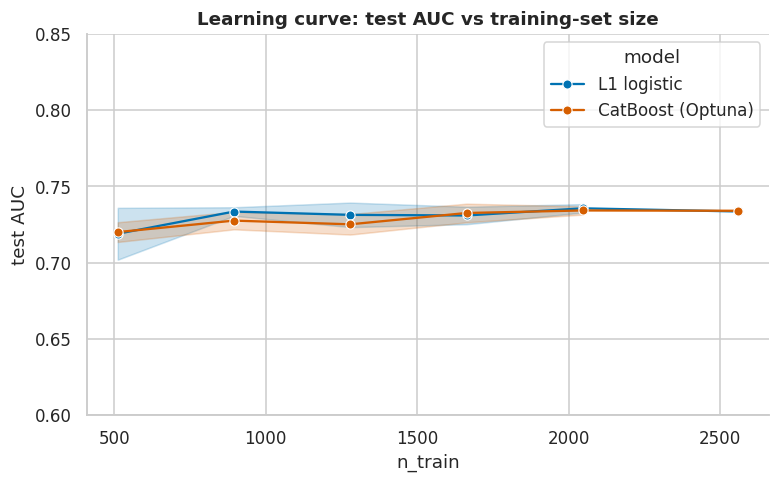

model,CatBoost (Optuna),L1 logistic
n_train,,
511,0.720,0.719
895,0.728,0.734
1279,0.725,0.731
1663,0.733,0.731
2047,0.734,0.736
2559,0.734,0.734


In [9]:
fracs = [0.2, 0.35, 0.5, 0.65, 0.8, 1.0]
rng = np.random.default_rng(SEED)
lc = []
for f in fracs:
    for rep_ in range(3):
        idx = rng.choice(len(ytr), int(f * len(ytr)), replace=False) if f < 1 else np.arange(len(ytr))
        for name, mk in [("L1 logistic", builders["L1 logistic (baseline)"][0]),
                         ("CatBoost (Optuna)", builders["CatBoost (Optuna)"][0])]:
            Xa = Xtr_cb if "Cat" in name else Xtr
            Xb = Xte_cb if "Cat" in name else Xte
            m = mk().fit(Xa.iloc[idx], ytr[idx])
            lc.append({"model": name, "n_train": len(idx), "test AUC": roc_auc_score(yte, m.predict_proba(Xb)[:, 1])})
        if f == 1:
            break
lc = pd.DataFrame(lc)
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.lineplot(data=lc, x="n_train", y="test AUC", hue="model", marker="o", errorbar="sd", ax=ax, palette=PALETTE[:2])
ax.set_ylim(0.6, 0.85); ax.set_title("Learning curve: test AUC vs training-set size")
save_fig(fig, "10_learning_curve"); plt.show()
lc.groupby(["model", "n_train"])["test AUC"].mean().unstack(0).round(3)

## 7. Where do 95 % results come from?

Same CatBoost model, raw `Status` target, different pipelines:

| # | Pipeline | Problem |
|---|---|---|
| P0 | predict "Alive" for everyone | baseline |
| P1 | split first, clinical inputs only | none |
| P2 | P1 + SMOTE on the training part | none |
| P3 | P1 + `Survival Months` as input | target leakage |
| P4 | SMOTE on all rows, then split | synthetic near-copies of training data in the test set; test set balanced 50/50 |
| P5 | P3 + P4 | both |

In [10]:
X_all, y_all, t_all = df[INPUT_COLS], df[C.EVENT_COL].to_numpy(), df[C.TIME_COL].to_numpy()
Xa, Xb, ya, yb, ta, tb = train_test_split(X_all, y_all, t_all, test_size=0.2, stratify=y_all, random_state=SEED)
prep = make_preprocessor(scale=False).fit(Xa)
A, B = prep.transform(Xa), prep.transform(Xb)
cbm = lambda: CatBoostClassifier(iterations=600, depth=4, learning_rate=0.05, verbose=0, random_seed=SEED)

scen = {}
scen["P0 all 'Alive'"] = report(yb, np.zeros(len(yb)), 0.5)
scen["P1 correct"] = report(yb, cbm().fit(A, ya).predict_proba(B)[:, 1], 0.5)
As, yas = SMOTE(random_state=SEED).fit_resample(A, ya)
scen["P2 SMOTE on train only"] = report(yb, cbm().fit(As, yas).predict_proba(B)[:, 1], 0.5)
scen["P3 + Survival Months (leak)"] = report(yb, cbm().fit(A.assign(sm=ta), ya).predict_proba(B.assign(sm=tb))[:, 1], 0.5)
Xfull = prep.transform(X_all)
for label, M in [("P4 SMOTE before split", Xfull), ("P5 leak + SMOTE before split", Xfull.assign(sm=t_all))]:
    Xs, ys = SMOTE(random_state=SEED).fit_resample(M, y_all)
    a, b, c, d = train_test_split(Xs, ys, test_size=0.2, stratify=ys, random_state=SEED)
    scen[label] = report(d, cbm().fit(a, c).predict_proba(b)[:, 1], 0.5)
scen = pd.DataFrame(scen).T
scen.to_csv(C.TABLES_DIR / "inflated_pipelines.csv")
scen.round(3)

,accuracy,precision (Dead),recall (Dead),F1 (Dead),F1 macro,F1 weighted,ROC-AUC
P0 all 'Alive',0.847,0.000,0.000,0.000,0.459,0.777,0.500
P1 correct,0.841,0.439,0.146,0.220,0.565,0.806,0.702
P2 SMOTE on train only,0.839,0.431,0.179,0.253,0.581,0.809,0.696
P3 + Survival Months (leak),0.911,0.800,0.553,0.654,0.801,0.904,0.846
P4 SMOTE before split,0.902,0.955,0.843,0.896,0.901,0.901,0.948
P5 leak + SMOTE before split,0.947,0.978,0.915,0.945,0.947,0.947,0.979


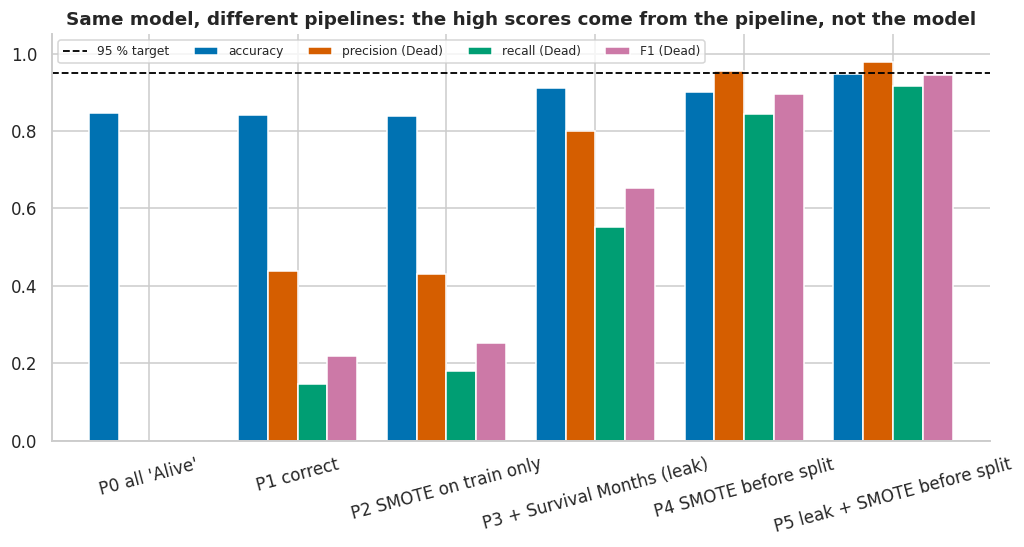

In [11]:
fig, ax = plt.subplots(figsize=(11, 4.8))
scen[["accuracy", "precision (Dead)", "recall (Dead)", "F1 (Dead)"]].plot.bar(ax=ax, color=PALETTE[:4], width=0.8)
ax.axhline(0.95, c="k", ls="--", lw=1.2, label="95 % target")
ax.set_ylim(0, 1.05); ax.tick_params(axis="x", rotation=15); ax.legend(ncol=5, fontsize=8, loc="upper left")
ax.set_title("Same model, different pipelines: the high scores come from the pipeline, not the model")
save_fig(fig, "10_inflated_pipelines"); plt.show()

- **SMOTE before the split:** synthetic test patients are built from training patients, and the balanced test set inflates precision.
- **`Survival Months`:** not known at diagnosis.

## Findings

| Check | Result |
|---|---|
| Best test AUC | 0.734 (tuned CatBoost; L1 logistic also 0.734) |
| Best test F1 (threshold from training data) | 0.42 |
| Best test F1 at any threshold | 0.42 |
| Thresholds with all four metrics ≥ 0.95 | 0 |
| Best accuracy at any threshold | 0.874 (all "survives": 0.860) |
| Tuning gain for CatBoost | +0.024 AUC in CV, +0.007 on test |
| Learning curve | flat at about 0.73 from ~1,300 patients |

The same CatBoost model goes from F1 0.22 to 0.95 only by changing the pipeline: `Survival Months` gives 0.65, SMOTE before the split gives 0.90, and both together give accuracy 0.947, precision 0.978, recall 0.915, F1 0.945.

95 % results on this dataset come from leakage and test contamination. The limit is missing information: treatment, HER2 status, comorbidity and cause of death are not in the data.